In [1]:
import glob
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import numpy as np
from regions import Regions
from astropy.nddata import Cutout2D
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from astropy.table import Table
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}




#nrca_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrca_indivexp_photometry_tables_merged.fits')
#nrcb_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/basic_nrcb_indivexp_photometry_tables_merged.fits')
#catalog_f140m_nrca = Table.read()
nrca_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined.fits')
nrcb_catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_after_merger_combined.fits')
test_regions = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f140m_refine_test.reg', format='crtf')
by_eye_sources = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/by_eye_star_f480m.reg', format='crtf')

ra_reg = []
dec_reg = []
for reg in by_eye_sources:
    ra_reg.append(reg.center.ra.deg)
    dec_reg.append(reg.center.dec.deg)
by_eye_skycoord = SkyCoord(ra=ra_reg*u.deg, dec=dec_reg*u.deg, frame='icrs')


(0.0, 5.0)

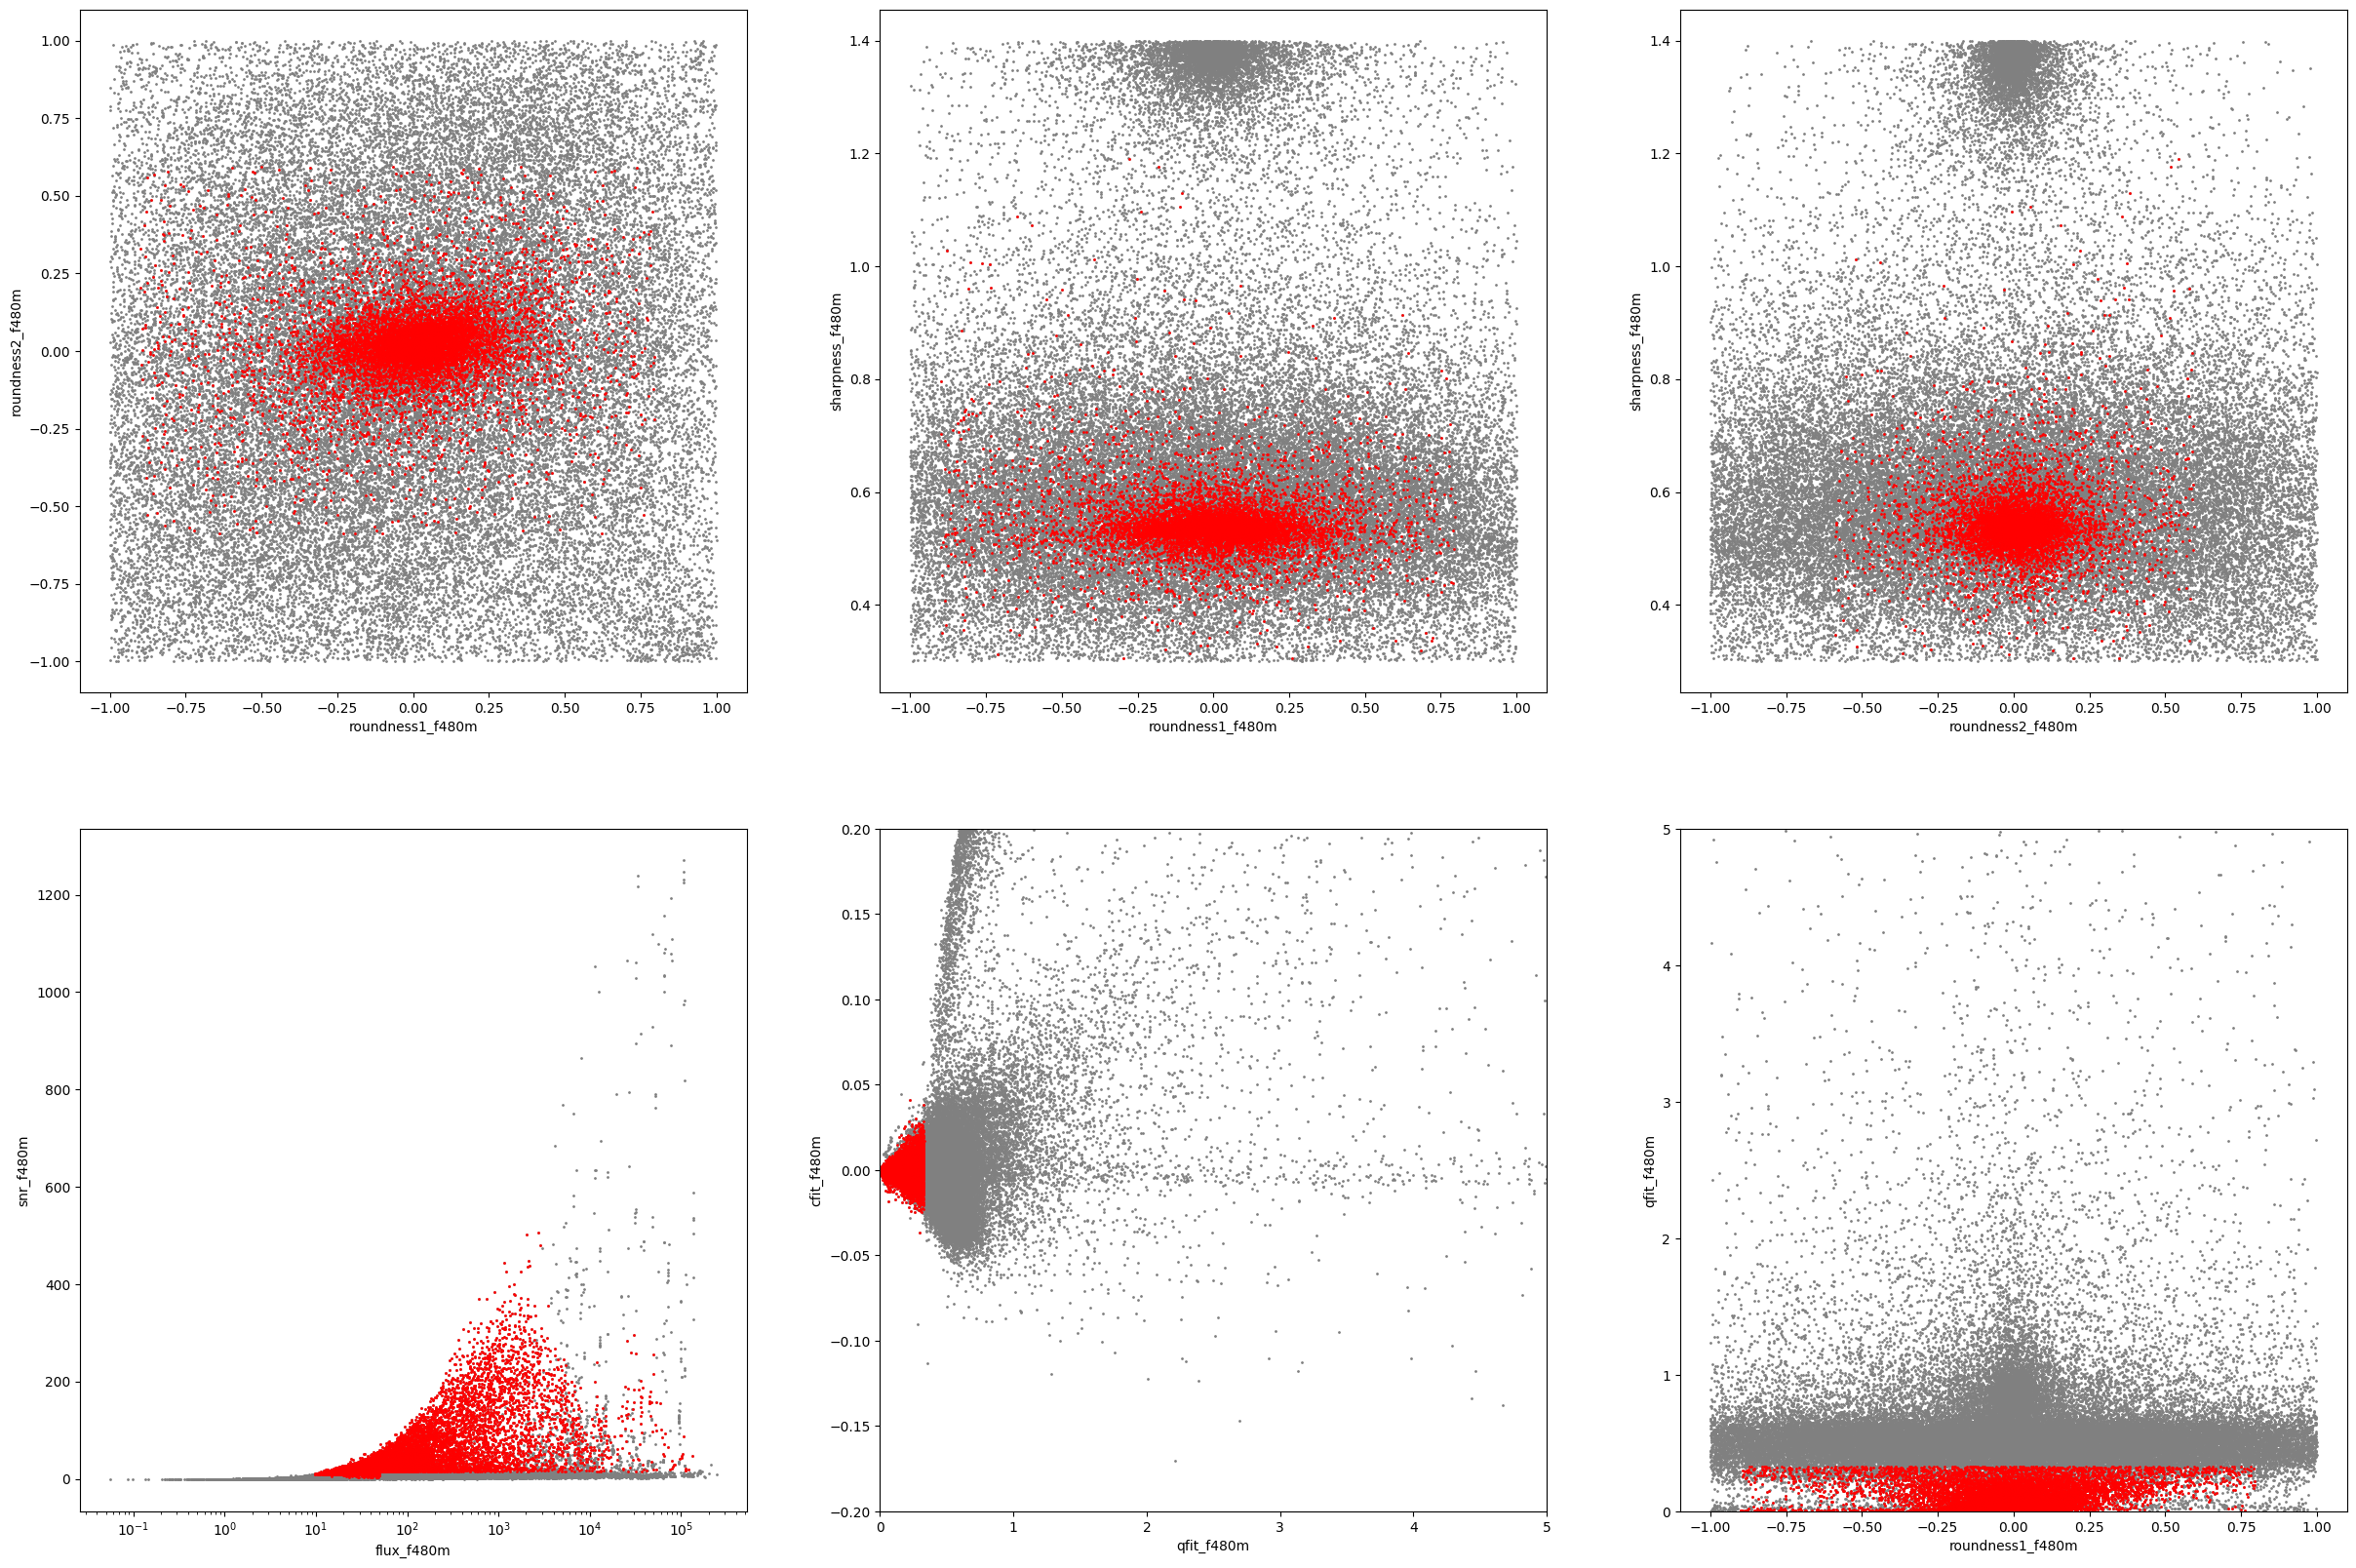

In [2]:
roundness1_f480m = nrca_catalog['roundness1']
roundness2_f480m = nrca_catalog['roundness2']
sharpness_f480m = nrca_catalog['sharpness']
flux_f480m = nrca_catalog['flux_fit']
fluxerr_f480m = nrca_catalog['flux_err']
snr_f480m = flux_f480m/fluxerr_f480m
qfit_f480m = nrca_catalog['qfit']
cfit_f480m = nrca_catalog['cfit']
skycoord = nrca_catalog['skycoord']


good_sources = ((roundness1_f480m < 0.8) & (roundness1_f480m > -0.9) & (roundness2_f480m < 0.6) & (roundness2_f480m > -0.6) & (sharpness_f480m < 1.2) & (sharpness_f480m>0.25) 
& (snr_f480m > 3) & (qfit_f480m < 0.33) & (cfit_f480m < 0.2) & (cfit_f480m > -0.2) & ~((snr_f480m < 15) & (flux_f480m > 50)))


fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f480m, roundness2_f480m, s=1, color='gray')
ax1.scatter(roundness1_f480m[good_sources], roundness2_f480m[good_sources], s=1, color='red')
ax1.set_xlabel('roundness1_f480m')
ax1.set_ylabel('roundness2_f480m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f480m, sharpness_f480m, s=1, color='gray')
ax2.scatter(roundness1_f480m[good_sources], sharpness_f480m[good_sources], s=1, color='red')
ax2.set_xlabel('roundness1_f480m')
ax2.set_ylabel('sharpness_f480m')   

ax3 = fig.add_subplot(233)
ax3.scatter(roundness2_f480m, sharpness_f480m, s=1, color='gray')
ax3.scatter(roundness2_f480m[good_sources], sharpness_f480m[good_sources], s=1, color='red')
ax3.set_xlabel('roundness2_f480m')
ax3.set_ylabel('sharpness_f480m')   

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f480m, snr_f480m, s=1, color='gray')
ax4.scatter(flux_f480m[good_sources], snr_f480m[good_sources], s=1, color='red')
ax4.set_xlabel('flux_f480m')
ax4.set_ylabel('snr_f480m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f480m, cfit_f480m, s=1, color='gray')
ax5.scatter(qfit_f480m[good_sources], cfit_f480m[good_sources], s=1, color='red')
ax5.set_xlabel('qfit_f480m')
ax5.set_ylabel('cfit_f480m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f480m, qfit_f480m, s=1, color='gray')
ax6.scatter(roundness1_f480m[good_sources], qfit_f480m[good_sources], s=1, color='red')
ax6.set_xlabel('roundness1_f480m')
ax6.set_ylabel('qfit_f480m')
ax6.set_ylim(0,5)




331 62007 331
[20558 19961 20283 20234 20114 20049 19755 20487 20385 20076 58358 20004
 19566 19219 19308 19449 19362 19159 19356 19341 19190 19135 18959 19006
 19602 19434 19134 18522 18500 18603 18566 18567 18651 18717 18359 18406
 19631 19844 20158 19689 19761 19730 19719 19564 27335 20573 20344 19312
 19401 19582 18855 18894 18829 18906 18905 18815 18648 18735 19029 19056
 19097 19238 19374 18545 18465 18574 18499 18536 18565 18551 18636 18747
 18728 18689 18666 18790 18777 18931 18791 19057 45007 45026 45108 45112
 45116 45041 45022 45025 45049 45042 45012 45058 45111 45078 54287 45117
 45141 45178 45155 45021 45106 45151 45131 45195 45212 45321 45275 45032
 45200 45159 45066 45234 45226 45208 45206 45183 45134 45324 45286 45268
 45246 45171 45295 45391 45366 45452 45445 45357 45410 45476 45422 45339
 45271 45281 45269 45296 45259 45414 45264 45388 45392 45177 45655 45658
 45633 45615 45597 45563 45580 45686 45690 51555 45711 45602 45501 45473
 45435 45405 45325 45889 45860 45950 

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


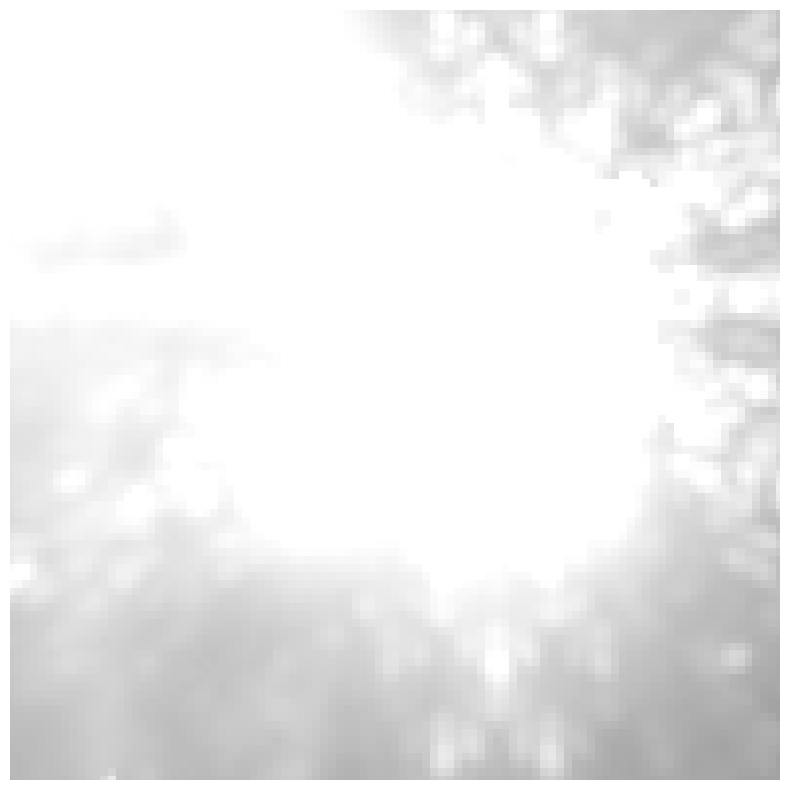

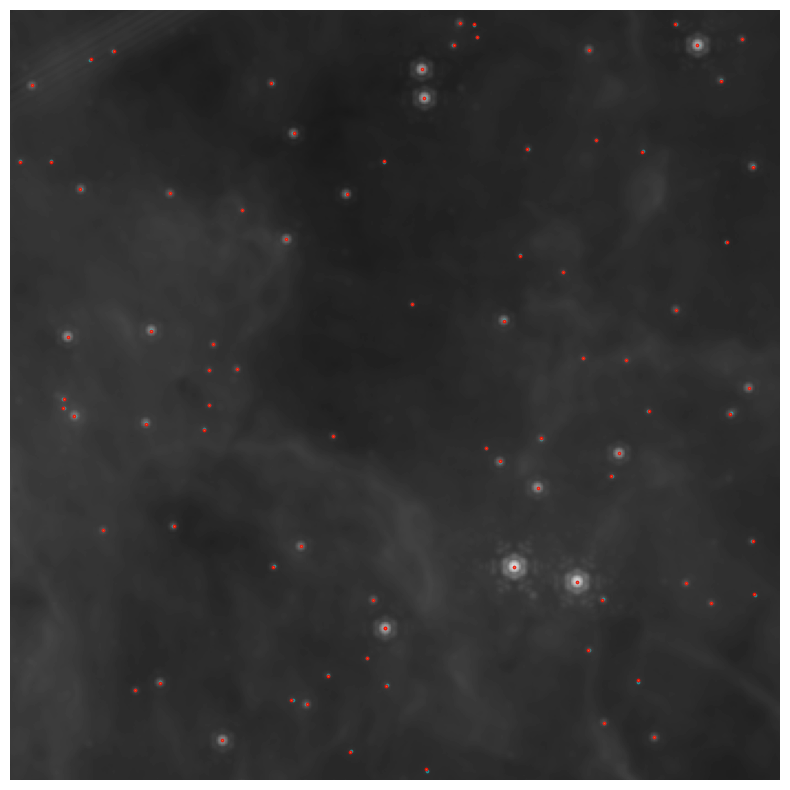

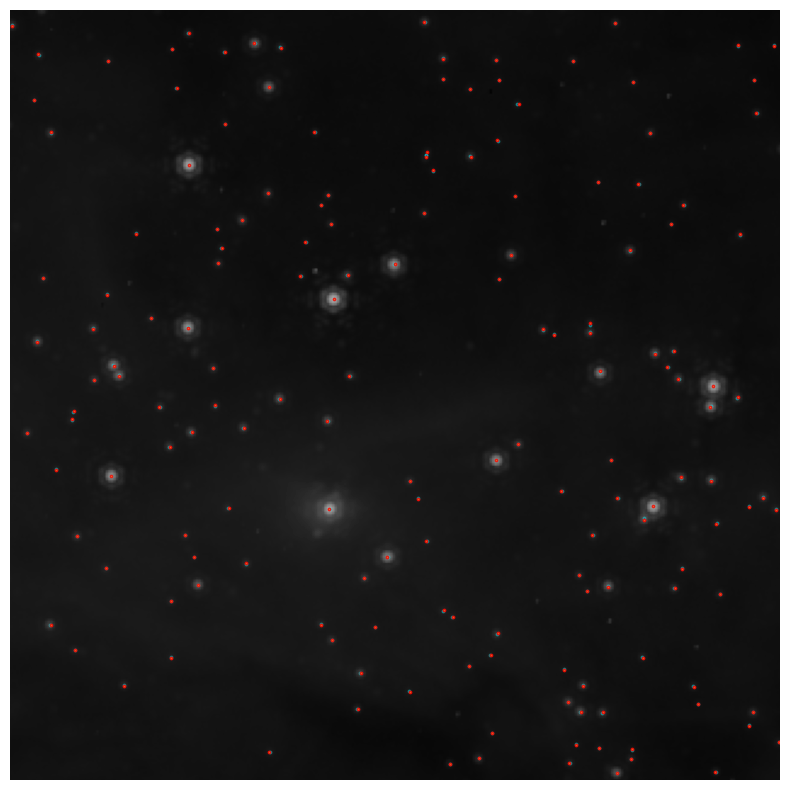

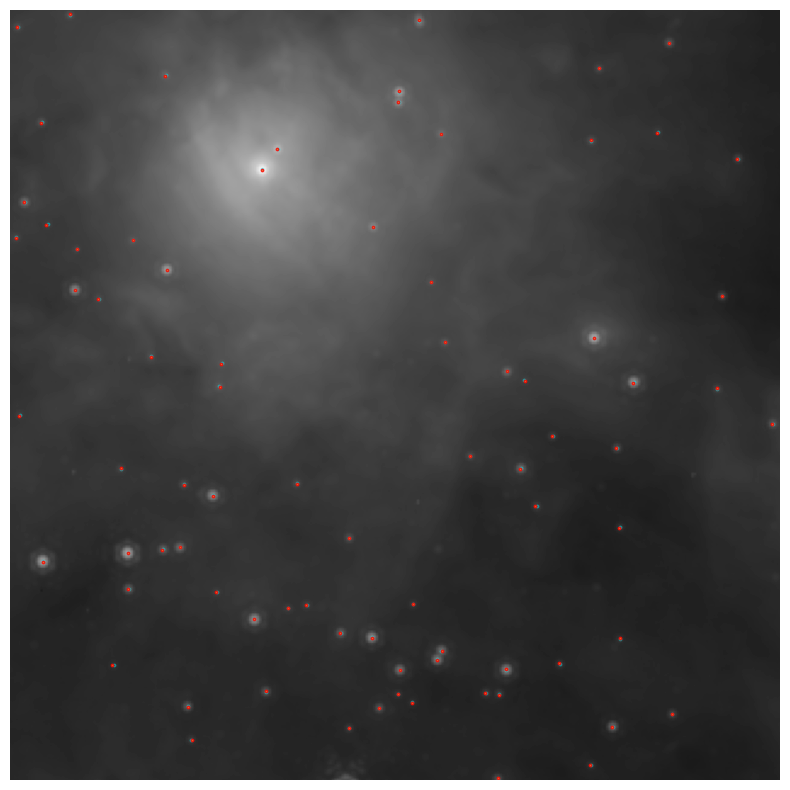

In [3]:
idx, d2d, d3d = by_eye_skycoord.match_to_catalog_sky(nrca_catalog['skycoord'])
print(len(idx), len(nrca_catalog['skycoord']), len(by_eye_skycoord))
print(idx)
matched = d2d < 0.1*u.arcsec
print(f'{len(matched==True)} sources out of {len(matched)} matched within 0.1 arcsec')
matched_skycoord = nrca_catalog['skycoord'][idx[matched]]
contains_arr = np.zeros(len(nrca_catalog['skycoord']), dtype=bool)
for reg in test_regions:
    filename = image_filenames['f480m']
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, reg.center, (reg.height, reg.width), wcs=wcs)
    norm = simple_norm(data, 'log', percent=99.95)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': cutout.wcs})
    ax.imshow(cutout.data, norm=norm, origin='lower', cmap='gray')
    skycoord_ref = nrca_catalog['skycoord']
    contains = reg.contains(skycoord_ref, wcs)
    contains_arr[contains] = True
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords_matched = cutout.wcs.world_to_pixel(matched_skycoord)
    pixcoords_by_eye_skycoord = cutout.wcs.world_to_pixel(by_eye_skycoord[matched])


    ra = pixcoords_matched[0]
    dec = pixcoords_matched[1]
    ax.scatter(ra, dec, s=3, edgecolor='cyan', alpha=0.4)
    ra = pixcoords_by_eye_skycoord[0]
    dec = pixcoords_by_eye_skycoord[1]
    ax.scatter(ra, dec, s=3, edgecolor='red', alpha=0.8)
    #ra = pixcoords[0][index] --- IGNORE
    ax.axis('off')
    ax.set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    ax.set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)

(0.0, 5.0)

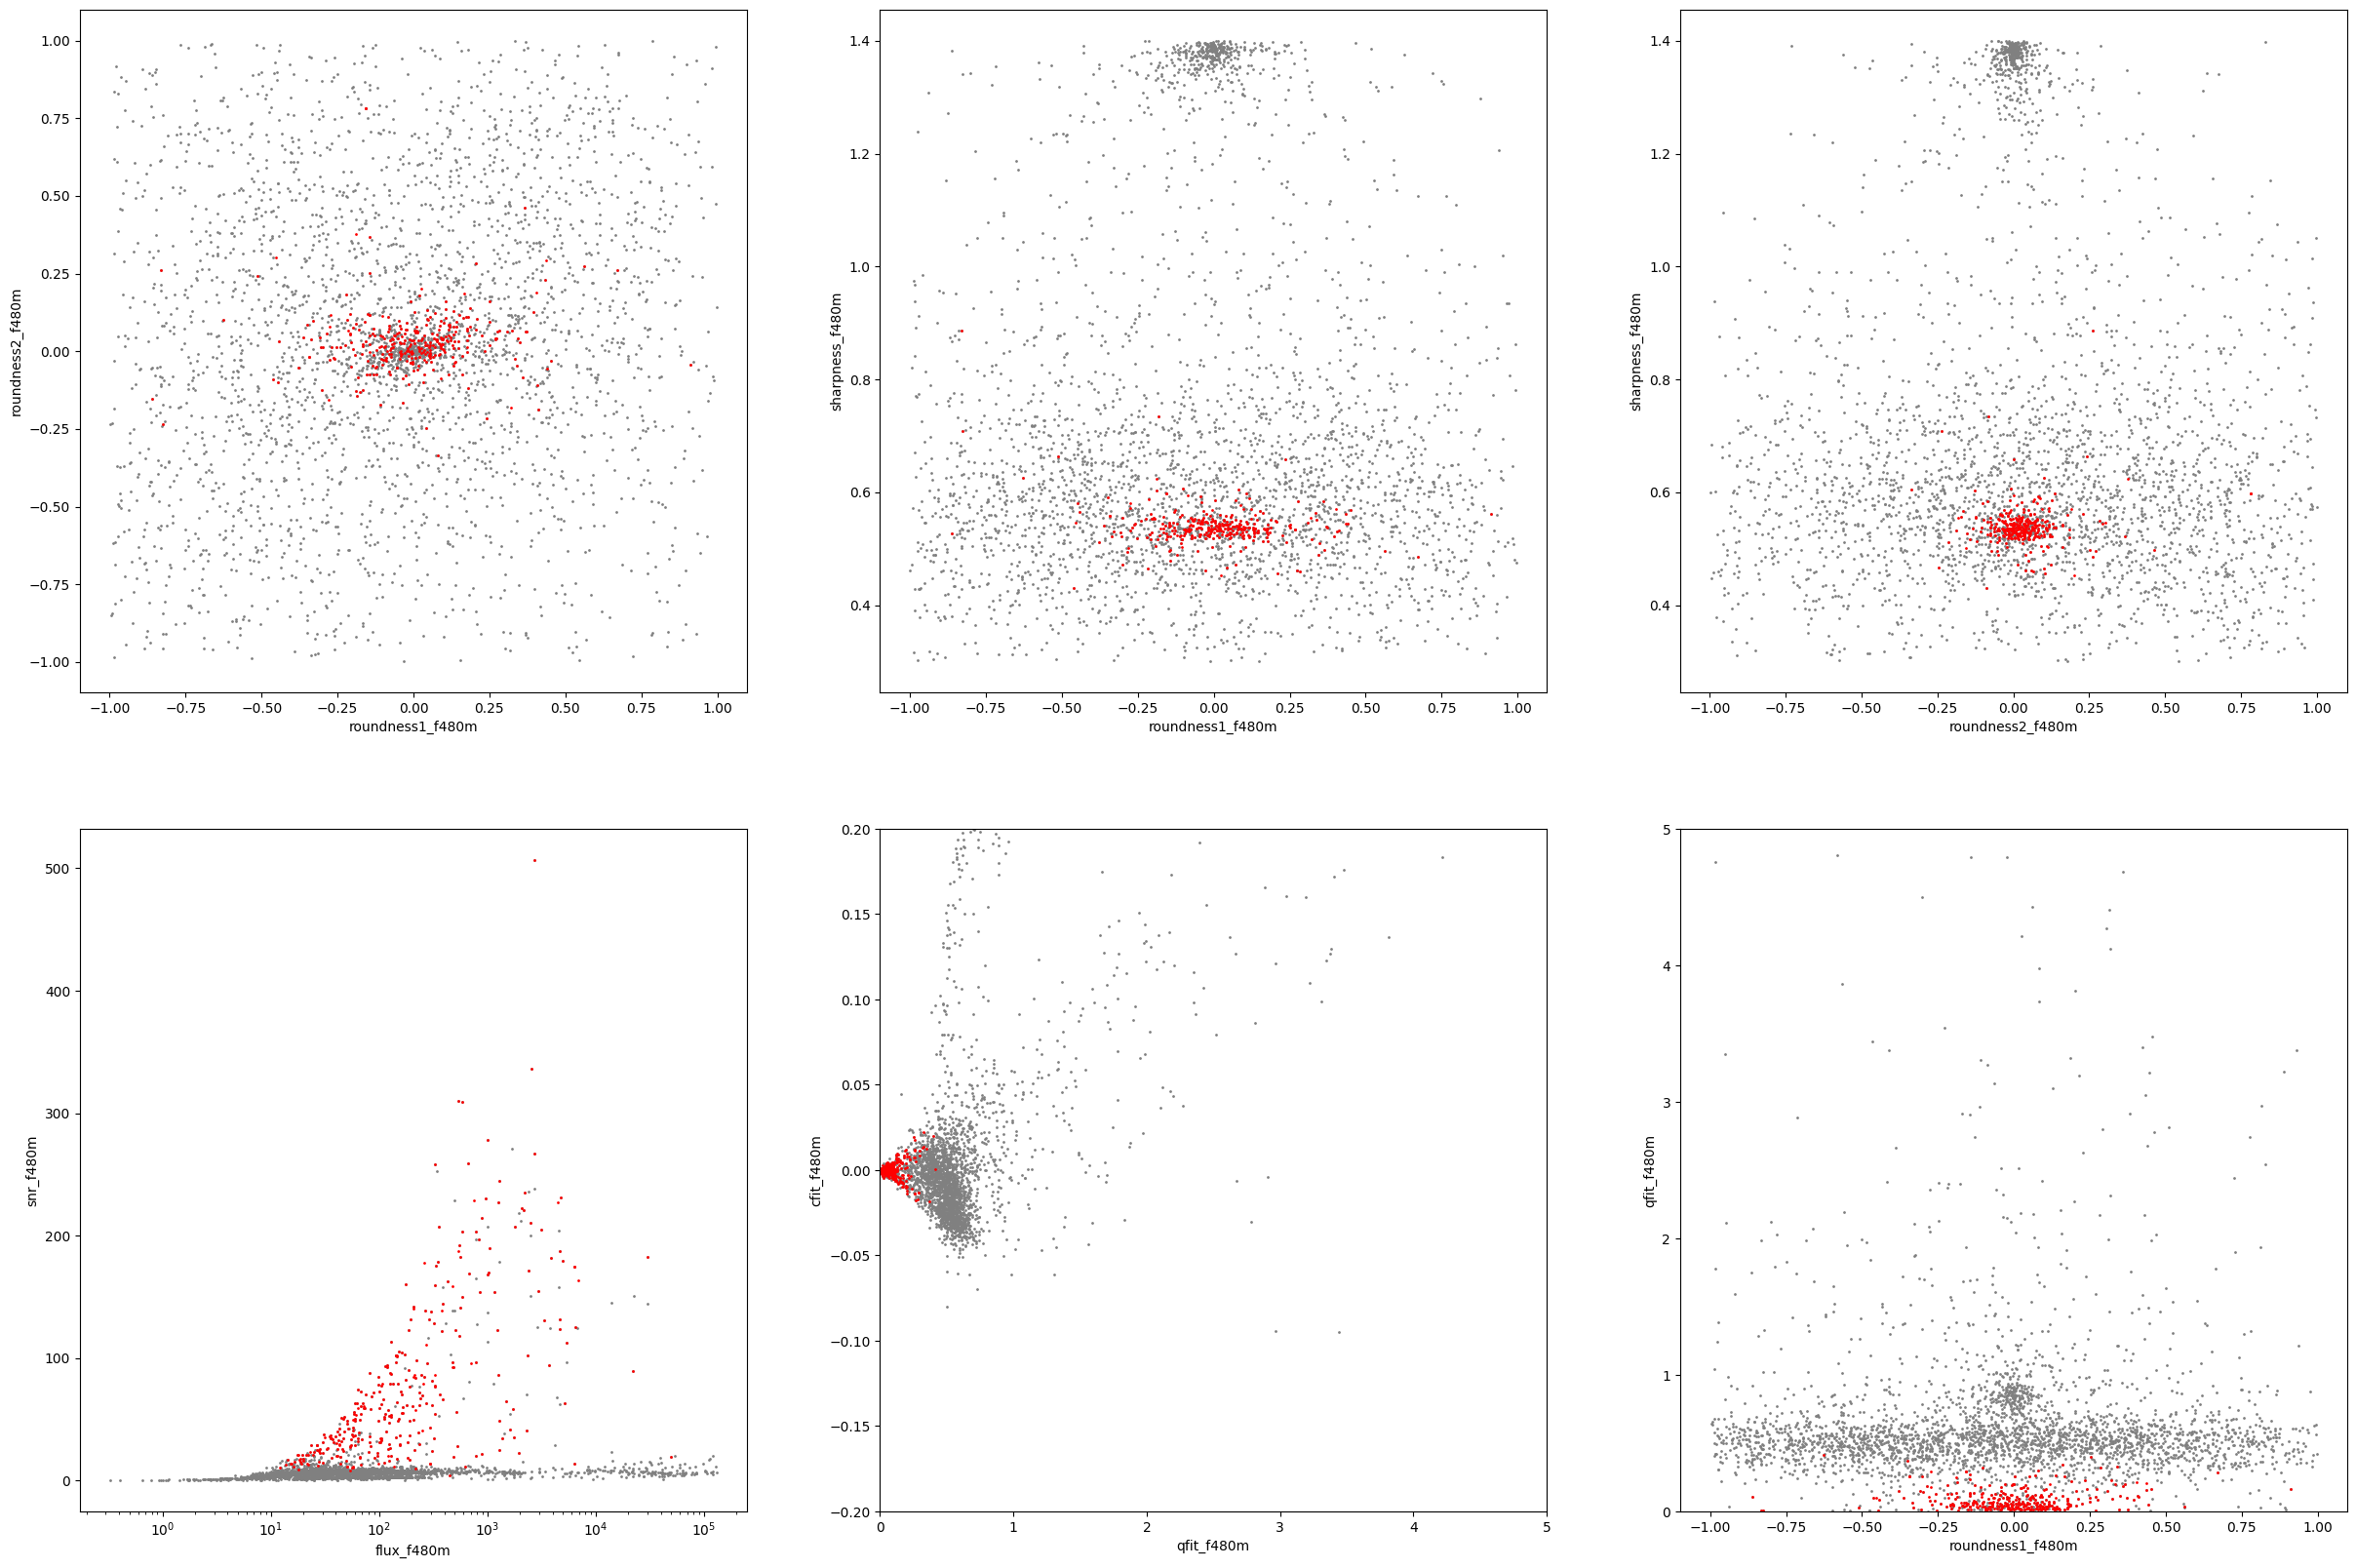

In [4]:
fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f480m[contains_arr], roundness2_f480m[contains_arr], s=1, color='gray')
ax1.scatter(roundness1_f480m[idx], roundness2_f480m[idx], s=1, color='red')
ax1.set_xlabel('roundness1_f480m')
ax1.set_ylabel('roundness2_f480m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f480m[contains_arr], sharpness_f480m[contains_arr], s=1, color='gray')
ax2.scatter(roundness1_f480m[idx], sharpness_f480m[idx], s=1, color='red')
ax2.set_xlabel('roundness1_f480m')
ax2.set_ylabel('sharpness_f480m')   

ax3 = fig.add_subplot(233)
ax3.scatter(roundness2_f480m[contains_arr], sharpness_f480m[contains_arr], s=1, color='gray')
ax3.scatter(roundness2_f480m[idx], sharpness_f480m[idx], s=1, color='red')
ax3.set_xlabel('roundness2_f480m')
ax3.set_ylabel('sharpness_f480m')   

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f480m[contains_arr], snr_f480m[contains_arr], s=1, color='gray')
ax4.scatter(flux_f480m[idx], snr_f480m[idx], s=1, color='red')
ax4.set_xlabel('flux_f480m')
ax4.set_ylabel('snr_f480m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f480m[contains_arr], cfit_f480m[contains_arr], s=1, color='gray')
ax5.scatter(qfit_f480m[idx], cfit_f480m[idx], s=1, color='red')
ax5.set_xlabel('qfit_f480m')
ax5.set_ylabel('cfit_f480m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f480m[contains_arr], qfit_f480m[contains_arr], s=1, color='gray')
ax6.scatter(roundness1_f480m[idx], qfit_f480m[idx], s=1, color='red')
ax6.set_xlabel('roundness1_f480m')
ax6.set_ylabel('qfit_f480m')
ax6.set_ylim(0,5)


(0.0, 5.0)

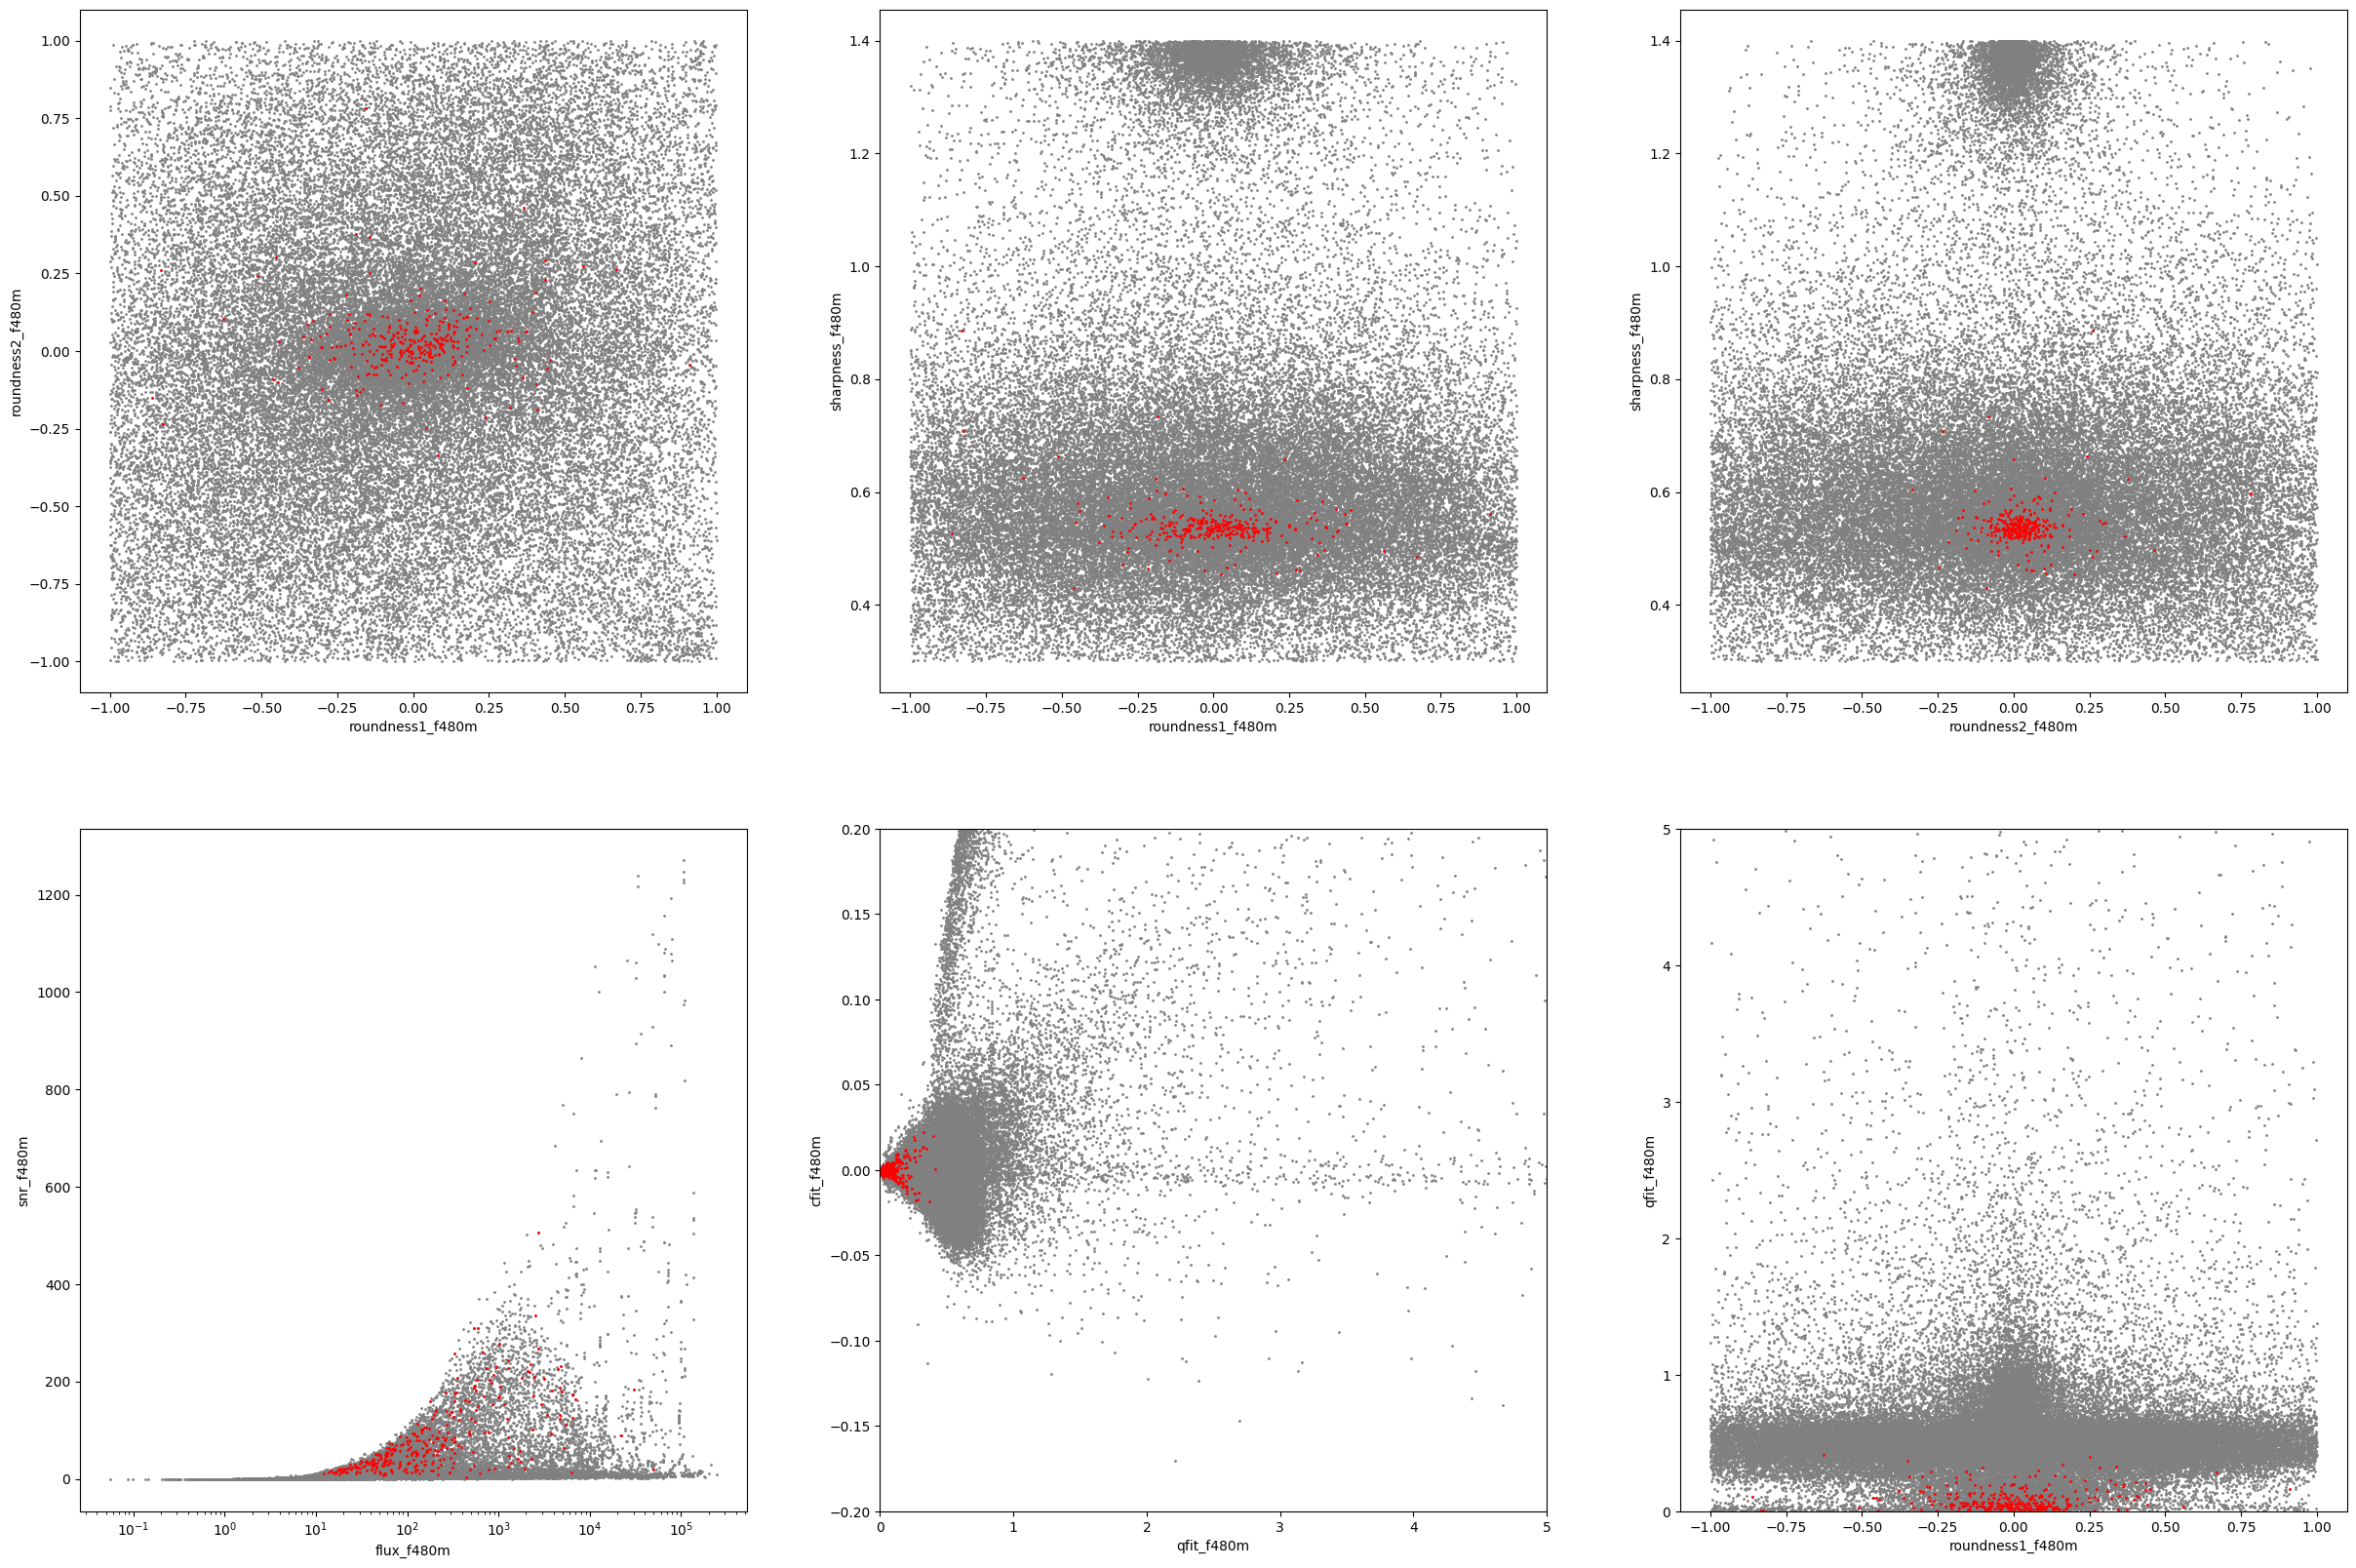

In [5]:
fig = plt.figure(figsize=(30,20))
ax1 = fig.add_subplot(231)
ax1.scatter(roundness1_f480m, roundness2_f480m, s=1, color='gray')
ax1.scatter(roundness1_f480m[idx], roundness2_f480m[idx], s=1, color='red')
ax1.set_xlabel('roundness1_f480m')
ax1.set_ylabel('roundness2_f480m')

ax2 = fig.add_subplot(232)
ax2.scatter(roundness1_f480m, sharpness_f480m, s=1, color='gray')
ax2.scatter(roundness1_f480m[idx], sharpness_f480m[idx], s=1, color='red')
ax2.set_xlabel('roundness1_f480m')
ax2.set_ylabel('sharpness_f480m')   

ax3 = fig.add_subplot(233)
ax3.scatter(roundness2_f480m, sharpness_f480m, s=1, color='gray')
ax3.scatter(roundness2_f480m[idx], sharpness_f480m[idx], s=1, color='red')
ax3.set_xlabel('roundness2_f480m')
ax3.set_ylabel('sharpness_f480m')   

ax4 = fig.add_subplot(234)
ax4.scatter(flux_f480m, snr_f480m, s=1, color='gray')
ax4.scatter(flux_f480m[idx], snr_f480m[idx], s=1, color='red')
ax4.set_xlabel('flux_f480m')
ax4.set_ylabel('snr_f480m') 
ax4.set_xscale('log')

ax5 = fig.add_subplot(235)
ax5.scatter(qfit_f480m, cfit_f480m, s=1, color='gray')
ax5.scatter(qfit_f480m[idx], cfit_f480m[idx], s=1, color='red')
ax5.set_xlabel('qfit_f480m')
ax5.set_ylabel('cfit_f480m')   
ax5.set_xlim(0,5)
ax5.set_ylim(-0.2, 0.2)

ax6 = fig.add_subplot(236)
ax6.scatter(roundness1_f480m, qfit_f480m, s=1, color='gray')
ax6.scatter(roundness1_f480m[idx], qfit_f480m[idx], s=1, color='red')
ax6.set_xlabel('roundness1_f480m')
ax6.set_ylabel('qfit_f480m')
ax6.set_ylim(0,5)

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


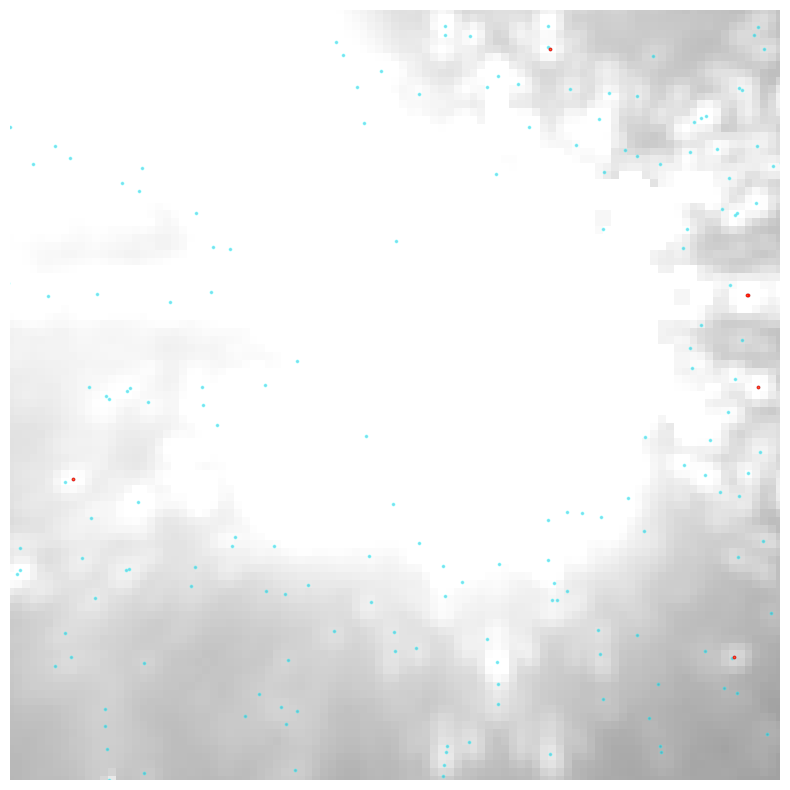

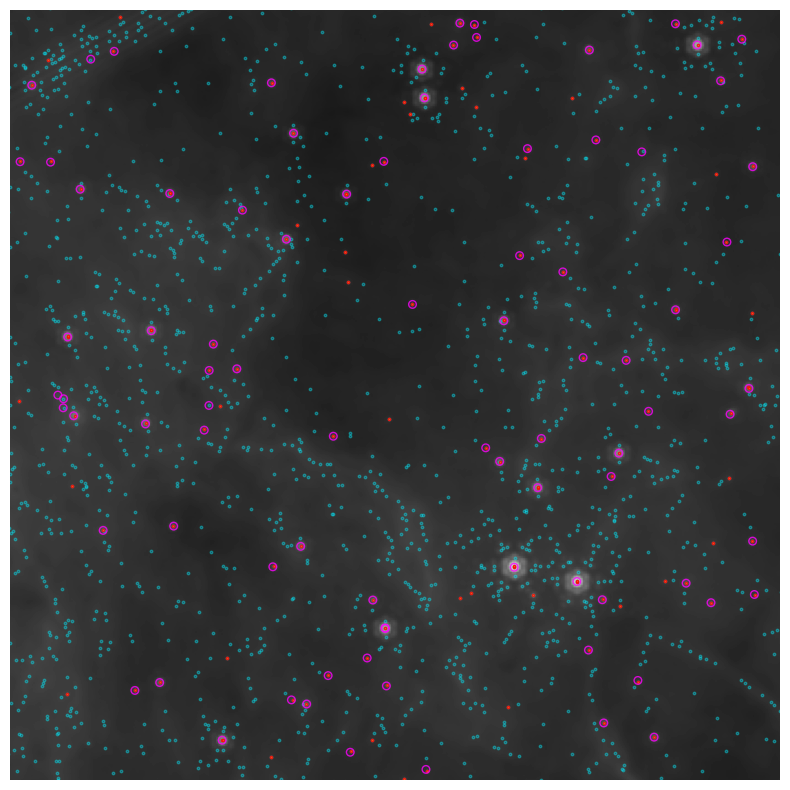

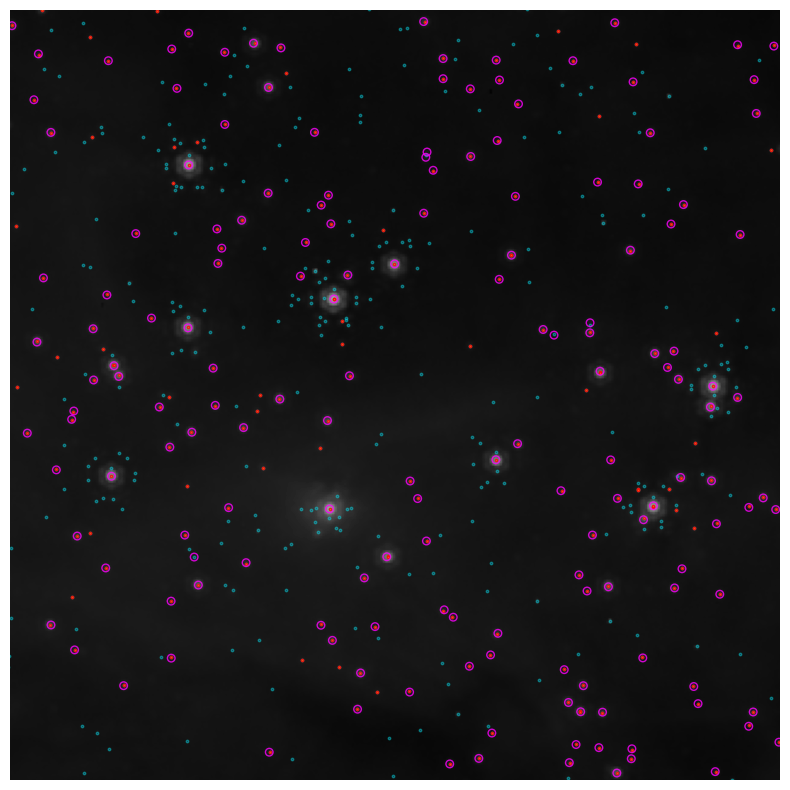

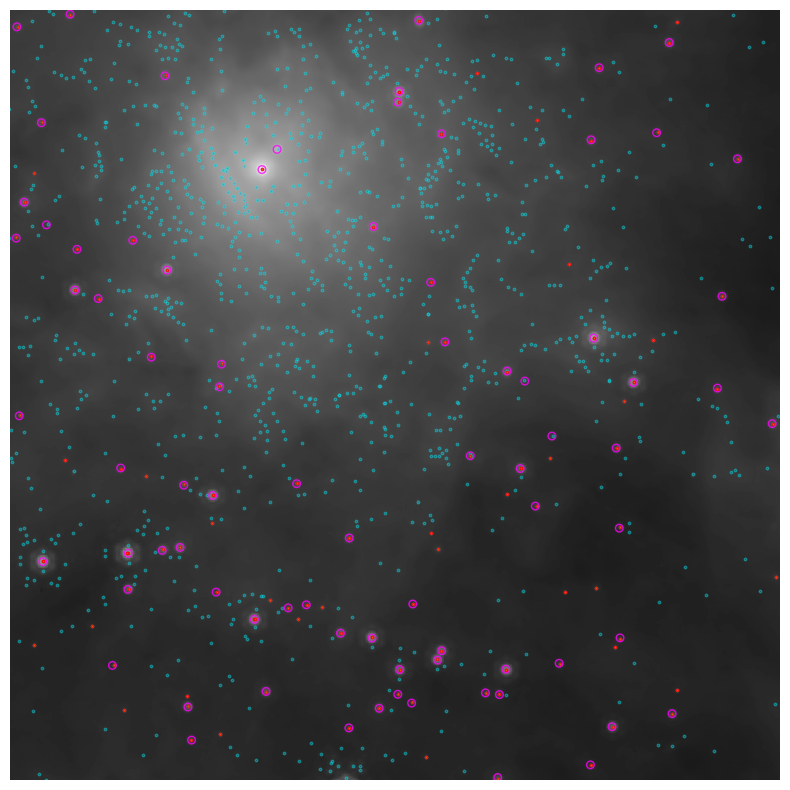

In [6]:





for reg in test_regions:
    filename = image_filenames['f480m']
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, reg.center, (reg.height, reg.width), wcs=wcs)
    norm = simple_norm(data, 'log', percent=99.95)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': cutout.wcs})
    ax.imshow(cutout.data, norm=norm, origin='lower', cmap='gray')
    skycoord_ref = nrca_catalog['skycoord']
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords = cutout.wcs.world_to_pixel(skycoord_ref)
    pixcoords_by_eye_skycoord = cutout.wcs.world_to_pixel(by_eye_skycoord)
  
    ra = pixcoords[0]
    dec = pixcoords[1]
    ax.scatter(ra, dec, s=3, edgecolor='cyan', alpha=0.4)
    ra = pixcoords[0][good_sources]
    dec = pixcoords[1][good_sources]
    ax.scatter(ra, dec, s=3, edgecolor='red', alpha=0.8)
    ra_by_eye = pixcoords_by_eye_skycoord[0]
    dec_by_eye = pixcoords_by_eye_skycoord[1]
    ax.scatter(ra_by_eye, dec_by_eye, s=30, edgecolor='magenta', facecolor='none', alpha=0.8)
    #ra = pixcoords[0][index] --- IGNORE
    ax.axis('off')
    ax.set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    ax.set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)


In [7]:
# found a group of sources that are close together within the pixel size


def remove_close_duplicates(nrca_catalog, pixel_scale=0.063*u.arcsec):
    """
    Remove sources from the catalog that are within 1 pixel of each other,
    keeping only the source with the lowest qfit value in each group.

    Parameters:
    -----------
    nrca_catalog : astropy Table
        The input catalog with 'skycoord' and 'qfit' columns.
    pixel_scale : astropy Quantity
        The pixel scale in arcseconds (default is 0.063 arcsec).

    Returns:
    --------
    filtered_catalog : astropy Table
        The catalog after removing close duplicates.
    """
    import numpy as np
    from astropy.coordinates import SkyCoord
    from astropy import units as u
    # Get sky coordinates
    skycoord = nrca_catalog['skycoord']
    qfit = nrca_catalog['qfit']

    # Find all pairs within 1 pixel
    idx1, idx2, sep2d, _ = skycoord.search_around_sky(skycoord, pixel_scale)

    # Remove self-matches
    mask = idx1 != idx2
    idx1 = idx1[mask]
    idx2 = idx2[mask]
    sep2d = sep2d[mask]

    # Grouping: for each star, find all neighbors within 1 pixel
    from collections import defaultdict
    neighbor_groups = defaultdict(set)
    for i1, i2 in zip(idx1, idx2):
        neighbor_groups[i1].add(i2)
        neighbor_groups[i2].add(i1)  # ensure symmetry

    # Find connected groups (clusters) using union-find
    parent = np.arange(len(skycoord))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i
    def union(i, j):
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pi] = pj
    for i1, i2 in zip(idx1, idx2):
        union(i1, i2)

    # Assign group ids
    group_ids = np.array([find(i) for i in range(len(skycoord))])

    # For each group, keep only the source with the lowest qfit
    unique_groups = np.unique(group_ids)
    keep_mask = np.zeros(len(skycoord), dtype=bool)
    for group in unique_groups:
        members = np.where(group_ids == group)[0]
        if len(members) == 1:
            keep_mask[members[0]] = True
        else:
            best = members[np.argmin(qfit[members])]
            keep_mask[best] = True
    print(f"Kept {np.sum(keep_mask)} out of {len(nrca_catalog)} sources after removing close duplicates.")

    return keep_mask




In [8]:
keep_mask_nrca = remove_close_duplicates(nrca_catalog, pixel_scale=0.063*u.arcsec)
keep_mask_nrcb = remove_close_duplicates(nrcb_catalog, pixel_scale=0.063*u.arcsec)

Kept 58472 out of 62007 sources after removing close duplicates.
Kept 70918 out of 75547 sources after removing close duplicates.


In [9]:
new_nrca_catalog = nrca_catalog[good_sources & keep_mask_nrca]
new_nrca_catalog.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_refined_after_sat.fits', overwrite=True)



In [10]:
good_sources_nrcb = ((nrcb_catalog['roundness1'] < 0.8) & (nrcb_catalog['roundness1'] > -0.9) & (nrcb_catalog['roundness2'] < 0.6) & (nrcb_catalog['roundness2'] > -0.6) & (nrcb_catalog['sharpness'] < 1.2) & (nrcb_catalog['sharpness']>0.25) 
& (nrcb_catalog['flux_fit']/nrcb_catalog['flux_err'] > 3) & (nrcb_catalog['qfit'] < 0.33) & (nrcb_catalog['cfit'] < 0.2) & (nrcb_catalog['cfit'] > -0.2) & ~((nrcb_catalog['flux_fit']/nrcb_catalog['flux_err'] < 20) & (nrcb_catalog['flux_fit'] > 50)) & (keep_mask_nrcb))
new_nrcb_catalog = nrcb_catalog[good_sources_nrcb]
new_nrcb_catalog.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrcb_indivexp_merged_dao_refined_after_sat.fits', overwrite=True)